In [1]:
#import necessary libraries
import sklearn
import pandas as pd
import numpy as np 
from sklearn import set_config
pd.set_option('display.max_columns',500)
pd.set_option('display.max_rows',200)
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from feature_engine.encoding import CountFrequencyEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='feature_engine')
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Importing and understanding the data, Explonatory data analysis, feature creation and manipulation,information value ,

In [2]:
data= pd.read_csv('application_train.csv')
df = data.copy()

In [3]:
data['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [4]:
data.shape

(307511, 122)

In [5]:
data.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


In [6]:
def iv(df, target, bins=10):
    def calc(col):
        f = pd.qcut(pd.to_numeric(df[col], errors="coerce"), bins, duplicates="drop") if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > bins else df[col]
        g = df.groupby(f, observed=True)[target].agg(e=lambda x: (x==1).sum(), n=lambda x: (x==0).sum())
        g = (g/g.sum()).replace(0, np.nan).dropna()
        g["woe"] = np.log(g.e / g.n)
        return ((g.e - g.n) * g.woe).sum(), g.woe.mean()
    scores = {c: calc(c) for c in df.columns if c != target}
    return pd.DataFrame({"Feature": scores.keys(), "IV Score": [v[0] for v in scores.values()], "Avg WoE": [v[1] for v in scores.values()]}).round(4).sort_values("IV Score", ascending=False).reset_index(drop=True)


result = iv(data,'TARGET')
dropcolumn = result[result["IV Score"] <= 0.02]["Feature"].tolist()
print(dropcolumn)
print(result)

['ELEVATORS_MEDI', 'ELEVATORS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'NAME_HOUSING_TYPE', 'LIVINGAPARTMENTS_MODE', 'NAME_CONTRACT_TYPE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'WALLSMATERIAL_MODE', 'LIVE_CITY_NOT_WORK_CITY', 'DEF_30_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_6', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'DEF_60_CNT_SOCIAL_CIRCLE', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'ENTRANCES_AVG', 'AMT_INCOME_TOTAL', 'ENTRANCES_MEDI', 'FLAG_WORK_PHONE', 'BASEMENTAREA_AVG', 'HOUR_APPR_PROCESS_START', 'BASEMENTAREA_MEDI', 'ENTRANCES_MODE', 'FLAG_PHONE', 'BASEMENTAREA_MODE', 'COMMONAREA_MODE', 'FLAG_OWN_CAR', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'CNT_FAM_MEMBERS', 'FLAG_DOCUMENT_13', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'FLAG_DOCUMENT_16', 'AMT_REQ_CREDIT_BUREAU_MON', 'NONLIVINGAPARTMENTS_AVG', '

In [9]:
data = data.drop(['ELEVATORS_MEDI','ELEVATORS_MODE',
                          'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG',
                          'NAME_HOUSING_TYPE', 'LIVINGAPARTMENTS_MODE',
                          'NAME_CONTRACT_TYPE', 'YEARS_BEGINEXPLUATATION_MEDI',
                          'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE',
                          'WALLSMATERIAL_MODE', 'LIVE_CITY_NOT_WORK_CITY', 
                          'DEF_30_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_6',
                          'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG',
                          'DEF_60_CNT_SOCIAL_CIRCLE', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'ENTRANCES_AVG',
                          'AMT_INCOME_TOTAL', 'ENTRANCES_MEDI', 'FLAG_WORK_PHONE', 
                          'BASEMENTAREA_AVG', 'HOUR_APPR_PROCESS_START', 'BASEMENTAREA_MEDI', 'ENTRANCES_MODE',
                          'FLAG_PHONE', 'BASEMENTAREA_MODE', 'COMMONAREA_MODE', 'FLAG_OWN_CAR',
                          'AMT_REQ_CREDIT_BUREAU_YEAR', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',
                          'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE',
                          'CNT_FAM_MEMBERS', 'FLAG_DOCUMENT_13', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
                          'FLAG_DOCUMENT_16', 'AMT_REQ_CREDIT_BUREAU_MON', 'NONLIVINGAPARTMENTS_AVG',
                          'NONLIVINGAPARTMENTS_MEDI', 'EMERGENCYSTATE_MODE', 'FLAG_DOCUMENT_14',
                          'NONLIVINGAPARTMENTS_MODE', 'CNT_CHILDREN', 'OBS_60_CNT_SOCIAL_CIRCLE',
                          'OBS_30_CNT_SOCIAL_CIRCLE', 'NAME_TYPE_SUITE', 'FLAG_DOCUMENT_18', 
                          'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_15', 'WEEKDAY_APPR_PROCESS_START', 
                          'AMT_REQ_CREDIT_BUREAU_QRT', 'REG_REGION_NOT_WORK_REGION', 'FLAG_OWN_REALTY', 
                          'AMT_REQ_CREDIT_BUREAU_DAY', 'REG_REGION_NOT_LIVE_REGION', 'SK_ID_CURR',
                          'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_2',
                          'FLAG_DOCUMENT_21', 'LIVE_REGION_NOT_WORK_REGION', 'AMT_REQ_CREDIT_BUREAU_WEEK', 
                          'FLAG_EMAIL', 'FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_4',
                          'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_12',
                          'AMT_REQ_CREDIT_BUREAU_HOUR', 'FLAG_DOCUMENT_20'],axis=1)

In [10]:
data.shape

(307511, 40)

In [11]:
data.sample(5)

,TARGET,CODE_GENDER,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,OCCUPATION_TYPE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,ELEVATORS_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,APARTMENTS_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,APARTMENTS_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,TOTALAREA_MODE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3
115647,0,M,225000.0,10944.0,225000.0,Working,Higher education,Single / not married,0.032561,-12300,-484,-6124.0,-4257,NaN,1,NaN,1,1,0,0,Other,NaN,0.705525,0.537070,0.4691,0.40,0.4583,NaN,0.2737,0.4779,0.4583,NaN,0.2852,0.4736,0.4583,NaN,0.2786,0.3708,-2828.0,0
270279,0,M,557770.5,20164.5,481500.0,Pensioner,Lower secondary,Married,0.020246,-21881,365243,-5609.0,-4318,NaN,0,NaN,3,3,0,0,XNA,NaN,0.033521,0.581484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2006.0,0
306709,0,F,1223010.0,48631.5,1125000.0,Working,Incomplete higher,Widow,0.032561,-17655,-6553,-7955.0,-1139,NaN,1,Managers,1,1,0,0,Trade: type 7,0.645845,0.624330,0.477649,0.1649,0.16,0.2500,NaN,0.1481,0.1681,0.2500,NaN,0.1543,0.1665,0.2500,NaN,0.1508,0.1165,-301.0,1
166856,0,F,671652.0,43051.5,607500.0,Working,Higher education,Married,0.024610,-13388,-2941,-4322.0,-665,NaN,1,NaN,2,2,0,0,Business Entity Type 1,NaN,0.244573,NaN,NaN,0.00,0.1667,0.2083,0.0407,NaN,0.1667,0.2083,0.0424,NaN,0.1667,0.2083,0.0414,0.0435,-35.0,1
275408,0,F,684000.0,27256.5,684000.0,State servant,Secondary / secondary special,Widow,0.026392,-22887,-13474,-1006.0,-4024,NaN,1,Laborers,2,2,0,0,Postal,NaN,0.700581,0.133429,0.0825,0.08,0.3750,NaN,0.0852,0.0840,0.3750,NaN,0.0888,0.0833,0.3750,NaN,0.0868,0.0670,-632.0,1


In [12]:
data.isna().sum()

TARGET                              0
CODE_GENDER                         0
AMT_CREDIT                          0
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
NAME_INCOME_TYPE                    0
NAME_EDUCATION_TYPE                 0
NAME_FAMILY_STATUS                  0
REGION_POPULATION_RELATIVE          0
DAYS_BIRTH                          0
DAYS_EMPLOYED                       0
DAYS_REGISTRATION                   0
DAYS_ID_PUBLISH                     0
OWN_CAR_AGE                    202929
FLAG_EMP_PHONE                      0
OCCUPATION_TYPE                 96391
REGION_RATING_CLIENT                0
REGION_RATING_CLIENT_W_CITY         0
REG_CITY_NOT_LIVE_CITY              0
REG_CITY_NOT_WORK_CITY              0
ORGANIZATION_TYPE                   0
EXT_SOURCE_1                   173378
EXT_SOURCE_2                      660
EXT_SOURCE_3                    60965
APARTMENTS_AVG                 156061
ELEVATORS_AVG                  163891
FLOORSMAX_AV

In [13]:
data.duplicated().sum()

np.int64(0)

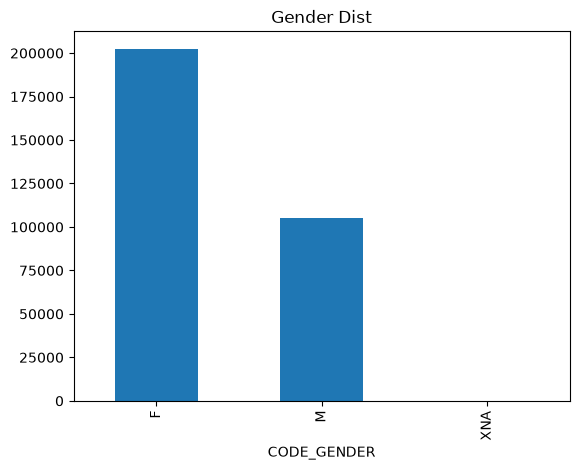

In [14]:
gender_distribution  = data['CODE_GENDER'].value_counts()
gender_distribution.plot(kind='bar')
plt.title('Gender Dist')
plt.show()

In [15]:
data.head(2)

,TARGET,CODE_GENDER,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,OCCUPATION_TYPE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,ELEVATORS_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,APARTMENTS_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,APARTMENTS_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,TOTALAREA_MODE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3
0,1,M,406597.5,24700.5,351000.0,Working,Secondary / secondary special,Single / not married,0.018801,-9461,-637,-3648.0,-2120,NaN,1,Laborers,2,2,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.00,0.0833,0.1250,0.0190,0.0252,0.0833,0.1250,0.0198,0.0250,0.0833,0.1250,0.0193,0.0149,-1134.0,1
1,0,F,1293502.5,35698.5,1129500.0,State servant,Higher education,Married,0.003541,-16765,-1188,-1186.0,-291,NaN,1,Core staff,1,1,0,0,School,0.311267,0.622246,NaN,0.0959,0.08,0.2917,0.3333,0.0549,0.0924,0.2917,0.3333,0.0554,0.0968,0.2917,0.3333,0.0558,0.0714,-828.0,1


<Axes: >

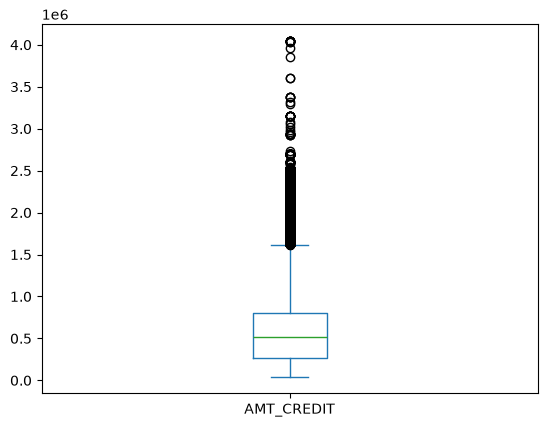

In [16]:
data['AMT_CREDIT'].plot(kind='box')

In [17]:
data.describe()

,TARGET,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,ELEVATORS_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,APARTMENTS_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,APARTMENTS_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,TOTALAREA_MODE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3
count,307511.000000,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,143620.000000,154491.000000,98869.000000,153161.000000,151450.000000,154491.000000,98869.000000,153161.000000,151450.000000,154491.000000,98869.000000,153161.000000,159080.000000,307510.000000,307511.000000
mean,0.080729,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.819889,2.052463,2.031521,0.078173,0.230454,0.502130,5.143927e-01,0.510853,0.11744,0.078942,0.226282,0.231894,0.107399,0.114231,0.222315,0.228058,0.105975,0.117850,0.225897,0.231625,0.108607,0.102547,-962.858788,0.710023
std,0.272419,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,1509.450419,11.944812,0.384280,0.509034,0.502737,0.268444,0.421124,0.211062,1.910602e-01,0.194844,0.10824,0.134576,0.144641,0.161380,0.110565,0.107936,0.143709,0.161160,0.111845,0.109076,0.145067,0.161934,0.112260,0.107462,826.808487,0.453752
min,0.000000,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.014568,8.173617e-08,0.000527,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000
25%,0.000000,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,-4299.000000,5.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.334007,3.924574e-01,0.370650,0.05770,0.000000,0.166700,0.083300,0.045300,0.052500,0.166700,0.083300,0.042700,0.058300,0.166700,0.083300,0.045700,0.041200,-1570.000000,0.000000
50%,0.000000,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,-4504.000000,-3254.000000,9.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.505998,5.659614e-01,0.535276,0.08760,0.000000,0.166700,0.208300,0.074500,0.084000,0.166700,0.208300,0.073100,0.086400,0.166700,0.208300,0.074900,0.068800,-757.000000,1.000000
75%,0.000000,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,-2010.000000,-1720.000000,15.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.675053,6.636171e-01,0.669057,0.14850,0.120000,0.333300,0.375000,0.129900,0.143900,0.333300,0.375000,0.125200,0.148900,0.333300,0.375000,0.130300,0.127600,-274.000000,1.000000
max,1.000000,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,0.000000,0.000000,91.000000,1.000000,3.000000,3.000000,1.000000,1.000000,0.962693,8.549997e-01,0.896010,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000


In [18]:
numerical_data = data.select_dtypes(include='number')

In [19]:
numerical_data.corr()

,TARGET,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,ELEVATORS_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,APARTMENTS_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,APARTMENTS_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,TOTALAREA_MODE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3
TARGET,1.000000,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,-0.044932,0.041975,0.051457,0.037612,0.045982,0.058899,0.060893,0.044395,0.050994,-0.155317,-0.160472,-0.178919,-0.029498,-0.034199,-0.044003,-0.033614,-0.032997,-0.027284,-0.043226,-0.032698,-0.030685,-0.029184,-0.043768,-0.033394,-0.032739,-0.032596,0.055218,0.044346
AMT_CREDIT,-0.030369,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,0.009621,-0.006575,-0.094191,0.065519,-0.101776,-0.110915,-0.026886,-0.018856,0.168429,0.131228,0.043516,0.060439,0.080635,0.103296,0.078832,0.072146,0.053072,0.100418,0.075485,0.064142,0.058682,0.102770,0.078375,0.070860,0.072818,-0.073701,0.096365
AMT_ANNUITY,-0.012817,0.770138,1.000000,0.775109,0.118429,0.009445,-0.104332,0.038514,0.011268,-0.097057,0.103533,-0.128525,-0.141682,-0.006214,0.000896,0.119398,0.125804,0.030752,0.076213,0.101439,0.130174,0.099812,0.089659,0.066401,0.126302,0.094457,0.079426,0.073987,0.129179,0.098642,0.088134,0.090415,-0.063747,0.102843
AMT_GOODS_PRICE,-0.039645,0.986968,0.775109,1.000000,0.103520,-0.053442,-0.064842,0.011565,-0.009267,-0.103733,0.063487,-0.103786,-0.112208,-0.027212,-0.020333,0.175502,0.139367,0.047717,0.064918,0.083736,0.108512,0.081411,0.077307,0.057523,0.105532,0.077770,0.069324,0.063187,0.107936,0.080863,0.076028,0.077527,-0.076313,0.074900
REGION_POPULATION_RELATIVE,-0.037227,0.099738,0.118429,0.103520,1.000000,-0.029582,-0.003980,-0.053820,-0.003993,-0.081429,0.004045,-0.532877,-0.531535,-0.050499,-0.044057,0.099997,0.198924,-0.006001,0.205942,0.280685,0.322652,0.294349,0.213491,0.175029,0.303992,0.275656,0.180932,0.201380,0.318319,0.290744,0.209347,0.202145,-0.044013,-0.084644
DAYS_BIRTH,0.078239,-0.055436,0.009445,-0.053442,-0.029582,1.000000,-0.615864,0.331912,0.272691,0.005761,0.619888,0.009361,0.008073,0.180382,0.242401,-0.600610,-0.091996,-0.205478,0.004779,-0.001448,0.001634,0.001538,-0.000334,0.004959,0.001294,0.000927,-0.000020,0.005092,0.001791,0.001735,0.000100,0.001329,0.082939,0.109666
DAYS_EMPLOYED,-0.044932,-0.066838,-0.104332,-0.064842,-0.003980,-0.615864,1.000000,-0.210242,-0.272378,0.028830,-0.999755,0.032750,0.034624,-0.090516,-0.254559,0.289848,-0.020767,0.113434,-0.016359,-0.009792,-0.015970,-0.015894,-0.012438,-0.014632,-0.015064,-0.015407,-0.010847,-0.016239,-0.016051,-0.016327,-0.012631,-0.015126,0.023032,-0.249082
DAYS_REGISTRATION,0.041975,0.009621,0.038514,0.011565,-0.053820,0.331912,-0.210242,1.000000,0.101896,-0.025991,0.212361,0.080210,0.074038,0.064334,0.099874,-0.181095,-0.059913,-0.107549,0.013186,0.000746,0.049701,0.021459,0.007419,0.012732,0.049657,0.020235,0.007457,0.013463,0.050076,0.021645,0.007926,0.019495,0.056983,0.033740
DAYS_ID_PUBLISH,0.051457,-0.006575,0.011268,-0.009267,-0.003993,0.272691,-0.272378,0.101896,1.000000,0.008633,0.273611,-0.005103,-0.007737,0.076326,0.099354,-0.132375,-0.050955,-0.131597,-0.007322,-0.010555,-0.010235,-0.008865,-0.011515,-0.007129,-0.010308,-0.008991,-0.012096,-0.007139,-0.010307,-0.008754,-0.011315,-0.011153,0.088576,0.050309
OWN_CAR_AGE,0.037612,-0.094191,-0.097057,-0.103733,-0.081429,0.005761,0.028830,-0.025991,0.008633,1.000000,-0.028282,0.087494,0.088820,0.009218,0.016292,-0.083411,-0.080753,-0.014604,-0.051177,-0.066454,-0.083690,-0.075332,-0.060352,-0.045409,-0.081211,-0.072489,-0.055302,-0.050102,-0.083250,-0.075454,-0.059040,-0.061298,0.002506,0.036403


Text(0.5, 1.0, 'corellation distribution')

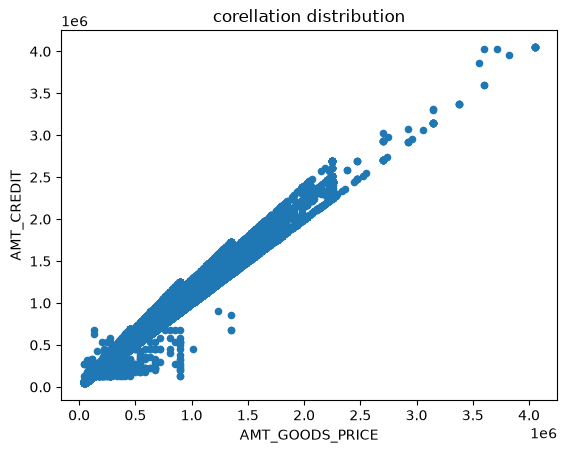

In [20]:
data.plot(kind='scatter',x='AMT_GOODS_PRICE',y='AMT_CREDIT')
plt.title('corellation distribution')

In [21]:
numerical_data.skew()

TARGET                         3.078159
AMT_CREDIT                     1.234778
AMT_ANNUITY                    1.579777
AMT_GOODS_PRICE                1.349000
REGION_POPULATION_RELATIVE     1.488009
DAYS_BIRTH                    -0.115673
DAYS_EMPLOYED                  1.664346
DAYS_REGISTRATION             -0.590872
DAYS_ID_PUBLISH                0.349327
OWN_CAR_AGE                    2.745422
FLAG_EMP_PHONE                -1.664886
REGION_RATING_CLIENT           0.087468
REGION_RATING_CLIENT_W_CITY    0.059730
REG_CITY_NOT_LIVE_CITY         3.142781
REG_CITY_NOT_WORK_CITY         1.280138
EXT_SOURCE_1                  -0.068755
EXT_SOURCE_2                  -0.793576
EXT_SOURCE_3                  -0.409390
APARTMENTS_AVG                 2.641836
ELEVATORS_AVG                  2.439429
FLOORSMAX_AVG                  1.226454
FLOORSMIN_AVG                  0.954197
LIVINGAREA_AVG                 2.854736
APARTMENTS_MODE                2.703052
FLOORSMAX_MODE                 1.244343


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.]),
 [Text(-1.0, 0, 'Working'),
  Text(0.0, 0, 'Businessman'),
  Text(1.0, 0, 'Commercial associate'),
  Text(2.0, 0, 'Maternity leave'),
  Text(3.0, 0, 'Pensioner'),
  Text(4.0, 0, 'State servant'),
  Text(5.0, 0, 'Student'),
  Text(6.0, 0, 'Unemployed'),
  Text(7.0, 0, 'Working'),
  Text(8.0, 0, '')])

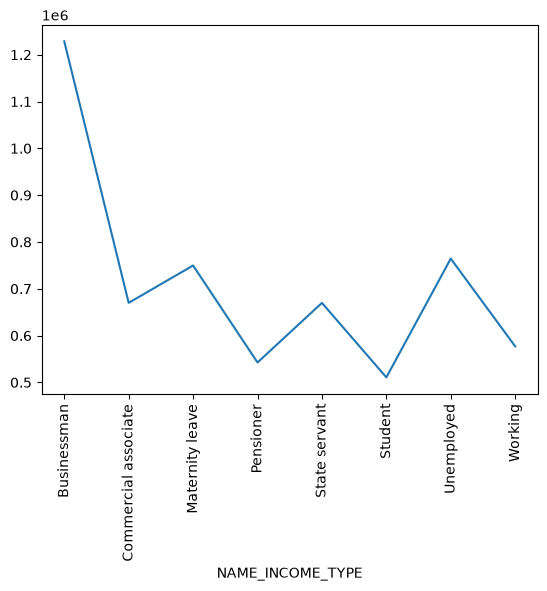

In [22]:
income_type =data.groupby('NAME_INCOME_TYPE')['AMT_CREDIT'].mean()
income_type.plot(kind='line')
plt.xticks(rotation=90)

In [23]:
data.groupby(['NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','OWN_CAR_AGE'])[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']].agg(['mean','sum','count'])

AMT_CREDIT  \
                                                                     mean   
NAME_EDUCATION_TYPE           NAME_FAMILY_STATUS OWN_CAR_AGE                
Academic degree               Civil marriage     1.0           607500.000   
                                                 4.0          1471491.000   
                                                 6.0          1125000.000   
                                                 9.0          1800000.000   
                                                 16.0          450000.000   
...                                                                   ...   
Secondary / secondary special Widow              45.0          393187.500   
                                                 47.0          239850.000   
                                                 51.0          542133.000   
                                                 64.0          645114.625   
                                                 65.0          541448.000   

                                                                          \
                                                                     sum   
NAME_EDUCATION_TYPE           NAME_FAMILY_STATUS OWN_CAR_AGE               
Academic degree               Civil marriage     1.0            607500.0   
                                                 4.0           1471491.0   
                                                 6.0           1125000.0   
                                                 9.0           1800000.0   
                                                 16.0           450000.0   
...                                                                  ...   
Secondary / secondary special Widow              45.0           786375.0   
                                                 47.0           239850.0   
                                                 51.0           542133.0   
                                                 64.0         23224126.5   
                                                 65.0          4873032.0   

                                                                    \
                                                             count   
NAME_EDUCATION_TYPE           NAME_FAMILY_STATUS OWN_CAR_AGE         
Academic degree               Civil marriage     1.0             1   
                                                 4.0             1   
                                                 6.0             1   
                                                 9.0             1   
                                                 16.0            1   
...                                                            ...   
Secondary / secondary special Widow              45.0            2   
                                                 47.0            1   
                                                 51.0            1   
                                                 64.0           36   
                                                 65.0            9   

                                                             AMT_ANNUITY  \
                                                                    mean   
NAME_EDUCATION_TYPE           NAME_FAMILY_STATUS OWN_CAR_AGE               
Academic degree               Civil marriage     1.0             16024.5   
                                                 4.0             80766.0   
                                                 6.0             46557.0   
                                                 9.0             74286.0   
                                                 16.0            35685.0   
...                                                                  ...   
Secondary / secondary special Widow              45.0            23458.5   
                                                 47.0            23850.0   
                                                 51.0            24007.5   
                          

Splitting of the data

In [24]:
X=data.drop('TARGET',axis=1)
y= data['TARGET']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

Feature engineering using pipeline 
Missing values 
encoding 
hyperparameter tuning
pipe the estimators with smote (imbalance dataset, winzorization outlier capping, scaling,pca)

In [26]:
categorical_data = data.select_dtypes(exclude='number')
categorical_data.sample(1)

,CODE_GENDER,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,OCCUPATION_TYPE,ORGANIZATION_TYPE
214007,M,Pensioner,Higher education,Single / not married,NaN,XNA


In [27]:
categorical_data['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [28]:
#missing data using simple imputer 
mean_missing = ['AMT_ANNUITY','AMT_GOODS_PRICE','OWN_CAR_AGE','EXT_SOURCE_1',
               'EXT_SOURCE_2','EXT_SOURCE_3','APARTMENTS_AVG','ELEVATORS_AVG',                 
                'FLOORSMAX_AVG','FLOORSMIN_AVG','LIVINGAREA_AVG','APARTMENTS_MODE',
                'FLOORSMAX_MODE','FLOORSMIN_MODE','LIVINGAREA_MODE','APARTMENTS_MEDI',
                'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI','LIVINGAREA_MEDI','TOTALAREA_MODE',
                'DAYS_LAST_PHONE_CHANGE','FLAG_DOCUMENT_3','AMT_CREDIT', 'REGION_POPULATION_RELATIVE',
                'DAYS_BIRTH', 'DAYS_EMPLOYED','DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE',
                 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
                'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY' ]
most_frequent = ['OCCUPATION_TYPE']
one_hot = ['CODE_GENDER','NAME_INCOME_TYPE',
           'NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS']
frequency = ['ORGANIZATION_TYPE']

In [29]:
mean_miss = Pipeline(steps=[(
    "MeanFormissing",SimpleImputer(missing_values=np.nan,strategy='mean'))])

In [30]:
most_freq = Pipeline(steps=[
    ("Mostfrequentformissing",SimpleImputer(missing_values=np.nan,strategy='most_frequent')),
    ('categorical_fre',CountFrequencyEncoder(encoding_method='count', missing_values='ignore'))
])

In [31]:
freq_encoder =Pipeline(steps=[("frequency",
                              CountFrequencyEncoder(encoding_method='count',
                                     missing_values='ignore'))
                             ])

In [32]:
onehot_encoder =Pipeline(steps=[
                         ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [33]:
%%writefile custom_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
def winsorize(X, lower=0.25, upper=0.75):
    Q1 = np.percentile(X, lower * 100, axis=0)
    Q3 = np.percentile(X, upper * 100, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)

class NamedWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.05, upper=0.95):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.feature_names_ = list(X.columns)
        return self

    def transform(self, X):
        return pd.DataFrame(winsorize(X, self.lower, self.upper),
                            columns=self.feature_names_, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)

Writing custom_transformers.py


In [34]:
from custom_transformers import winsorize, NamedWinsorizer
#winsorization_pipeline = Pipeline(steps=[
#    ("winsorization", NamedWinsorizer(lower=0.05, upper=0.95))
#])

In [35]:
preprocess = ColumnTransformer([
    ('MeanFormissing',         mean_miss,      mean_missing),
    ('Mostfrequentformissing', most_freq,      most_frequent),
    ('FrequencyEncoder',       freq_encoder,   frequency),
    ('Onehotencoder',          onehot_encoder, one_hot)
],remainder='passthrough')

In [36]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MeanFormissing', ...), ('Mostfrequentformissing', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names:

In [ ]:
# scale_pos_weight=93362/8117,
#                               eta = 0.1, 
#                               depth= 10, 
#                               subsample=1.0, 
#                               min_child_weight = 5,
#                               col_sample_bytree = 0.8,
#                               objective = 'binary:logistic'

# # random forest(n_estimators = 500,
# #                                         max_features ='sqrt',
# #                                         max_depth= 10)))

In [37]:
pipe = imbpipeline(steps=[
    ('ColumnTransformer', preprocess),
   ('OutlierCapping', NamedWinsorizer(lower=0.05, upper=0.95)),  
   ('SMOTE', SMOTE(sampling_strategy='minority', random_state=42)),
    ('SCALER', StandardScaler()),                                  
    ('xgboost', XGBClassifier(scale_pos_weight=93362/8117,
                              eta = 0.1, 
                              depth= 10, 
                              subsample=1.0, 
                              min_child_weight = 5,
                              col_sample_bytree = 0.8,
                              objective = 'binary:logistic'))
     ])

In [38]:
pipe

,steps,"[('ColumnTransformer', ...), ('OutlierCapping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MeanFormissing', ...), ('Mostfrequentformissing', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature 

In [ ]:
# grid = {
#     'XGBOOST__learning_rate'  : [0.01, 0.05, 0.1, 0.3],
#     'XGBOOST__n_estimators'   : [100, 300, 500],         
#     'XGBOOST__max_depth'      : [4, 6, 8, 10],
#     'XGBOOST__subsample'      : [0.6, 0.7, 0.8, 1.0],   
#     'XGBOOST__colsample_bytree': [0.6, 0.8, 1.0],
#     'XGBOOST__min_child_weight': [1, 3, 5],               
# }

In [ ]:
# warnings.filterwarnings('ignore')
# X_sample, y_sample = resample(X_train, y_train, n_samples=1000, random_state=42)
# search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=grid,
#     n_iter=20,
#     cv=5, 
#     n_jobs=-1, 
#     random_state=42
# )
# search.fit(X_sample, y_sample)
# pipe = search.best_estimator_

In [ ]:
# print("Best params:", search.best_params_)
# print("Best score:", search.best_score_)

In [39]:
pipe.set_output(transform="pandas")
pipe.fit(X_train,y_train)

c:\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col_sample_bytree", "depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('ColumnTransformer', ...), ('OutlierCapping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](39,)","['CODE_GENDER','AMT_CREDIT','AMT_ANNUITY',...,'TOTALAREA_MODE', 'DAYS_LAST_PHONE_CHANGE','FLAG_DOCUMENT_3']"
n_features_in_,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MeanFormissing', ...), ('Mostfrequentformissing', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [40]:
#probability of default
y_pred_prb = pipe.predict_proba(X_test)[:, 1]
print(y_pred_prb)

[0.7780431  0.3549562  0.76333195 ... 0.57448745 0.58422256 0.3253446 ]


In [41]:
# Compare train vs test performance for overfitting 
y_pred_sm = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

Train accuracy: 0.6226071678185913
Test accuracy: 0.6126587766927147


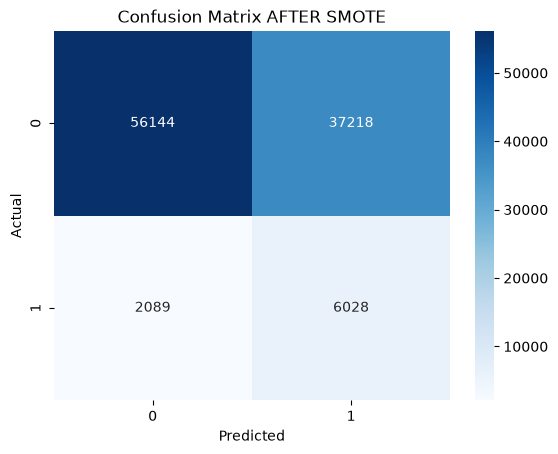

In [42]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

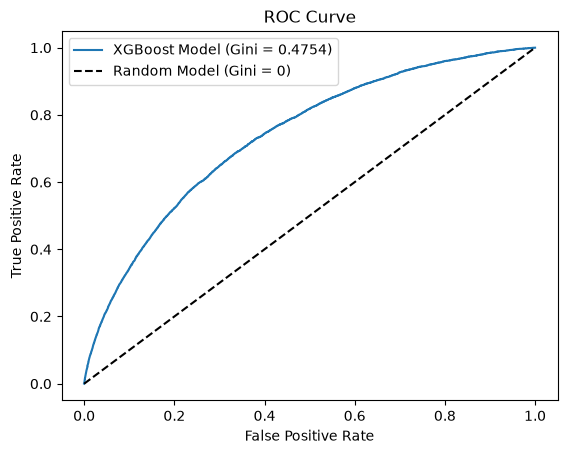

In [43]:
#gini coefficient evaluation on xgboost
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
gini = 2 * roc_auc_score(y_test, y_pred_proba) - 1

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"XGBoost Model (Gini = {gini:.4f})")
plt.plot([0,1],[0,1],"k--", label="Random Model (Gini = 0)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.show()

In [ ]:
# #threshold optimization

# cost_missed_default = 10  
# cost_false_alarm    = 1     

# best_threshold, best_cost = 0.5, float("inf")
# for threshold in np.arange(0.01, 0.99, 0.01):
#     y_pred_t = (pipe.predict_proba(X_test)[:, 1] >= threshold).astype(int)
#     fn = ((y_pred_t == 0) & (y_test == 1)).sum()
#     fp = ((y_pred_t == 1) & (y_test == 0)).sum()   
#     cost = fn * cost_missed_default + fp * cost_false_alarm
#     if cost < best_cost:
#         best_cost, best_threshold = cost, threshold

# print(f"Optimal threshold: {best_threshold:.2f}")

KS Statistic: 0.3514
P-value:      0.0000


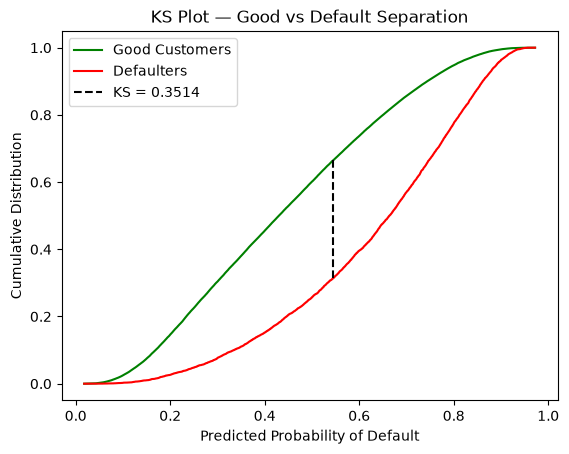

In [44]:
#ks to evaluate the model
def plot_ks(y_test, y_proba):
    # Split scores by class
    scores_good    = y_proba[y_test == 0]
    scores_default = y_proba[y_test == 1]

    # KS statistic
    ks_stat, p_value = ks_2samp(scores_good, scores_default)
    print(f"KS Statistic: {ks_stat:.4f}")
    print(f"P-value:      {p_value:.4f}")

    # Plot
    sorted_scores = np.sort(y_proba)
    cdf_good    = np.searchsorted(np.sort(scores_good),    sorted_scores, side='right') / len(scores_good)
    cdf_default = np.searchsorted(np.sort(scores_default), sorted_scores, side='right') / len(scores_default)

    ks_x = sorted_scores[np.argmax(np.abs(cdf_default - cdf_good))]
    ks_y1 = cdf_good[np.argmax(np.abs(cdf_default - cdf_good))]
    ks_y2 = cdf_default[np.argmax(np.abs(cdf_default - cdf_good))]

    plt.plot(sorted_scores, cdf_good,    label="Good Customers",  color="green")
    plt.plot(sorted_scores, cdf_default, label="Defaulters",      color="red")
    plt.vlines(ks_x, ks_y1, ks_y2, color="black", linestyle="--",
               label=f"KS = {ks_stat:.4f}")
    plt.xlabel("Predicted Probability of Default")
    plt.ylabel("Cumulative Distribution")
    plt.title("KS Plot — Good vs Default Separation")
    plt.legend()
    plt.show()
    return ks_stat

y_proba = pipe.predict_proba(X_test)[:, 1]
ks = plot_ks(y_test.values, y_proba)

In [45]:
#cross validation of stratifiedkfold on auc
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(pipe, X_train, y_train, 
                              cv=cv, scoring='roc_auc')

print(f"AUC per fold:  {auc_scores.round(4)}")
print(f"Mean AUC:      {auc_scores.mean():.4f}")
print(f"Std AUC:       {auc_scores.std():.4f}")  

#convert to auc to Gini
gini_scores = 2 * auc_scores - 1
print(f"\nGini per fold: {gini_scores.round(4)}")
print(f"Mean Gini:     {gini_scores.mean():.4f}")

c:\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col_sample_bytree", "depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col_sample_bytree", "depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col_sample_bytree", "depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:15:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "col_sample_bytree", "depth" } are not used.

  bst.update(dtrain, iterati

AUC per fold:  [0.7365 0.7341 0.7305 0.737  0.7347]
Mean AUC:      0.7345
Std AUC:       0.0023

Gini per fold: [0.473  0.4681 0.4609 0.474  0.4695]
Mean Gini:     0.4691


In [46]:
#classifying the probability default ranking 
def predict_default(model, X):
    prob       = model.predict_proba(X)[:, 1]
    prediction = model.predict(X)

    results = pd.DataFrame({
        'index'               : X.index,
        'probability_default' : prob,
        'predicted_default'   : prediction,
        'risk_tier'           : pd.cut(
                                    prob,
                                    bins=[0, 0.3, 0.6, 1.0],
                                    labels=['Low Risk', 'Medium Risk', 'High Risk']
                                )
    })
    
    return results.sort_values('probability_default', ascending=False)


predictions = predict_default(pipe, X_test)
print(predictions.sample(10))

         index  probability_default  predicted_default    risk_tier
972     186923             0.469854                  0  Medium Risk
14205     5518             0.599713                  1  Medium Risk
74241    42603             0.559075                  1  Medium Risk
101318  236165             0.281597                  0     Low Risk
61579    33986             0.322830                  0  Medium Risk
31291   152777             0.211186                  0     Low Risk
11797   235074             0.487617                  0  Medium Risk
84603   256856             0.493006                  0  Medium Risk
28080   232663             0.531942                  1  Medium Risk
32740    48083             0.178387                  0     Low Risk


In [47]:
#extracting the model from the pipeline 
xgb_model = pipe.named_steps['xgboost']

In [48]:
x_test_transformed = pipe.named_steps['ColumnTransformer'].transform(X_test)

c:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 101479 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=101479 when initializing the masker.
100%|===================| 101156/101479 [02:19<00:00]       

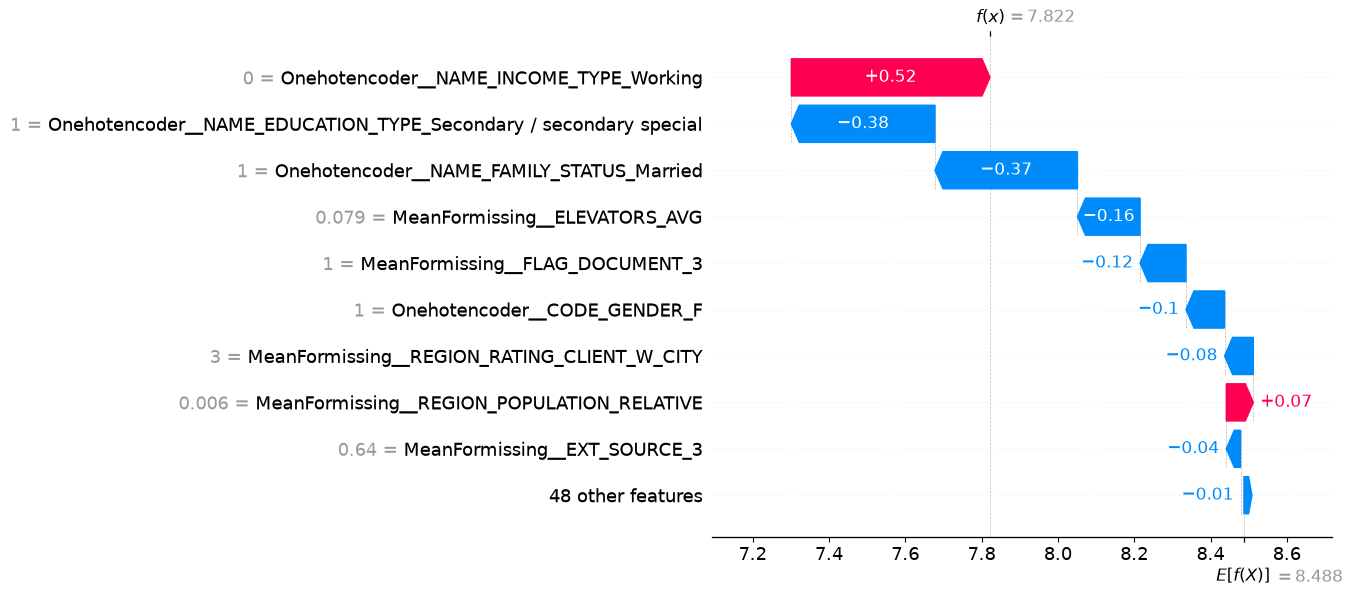

In [49]:
#using the shap explainer 
import shap
explainer = shap.Explainer(xgb_model,x_test_transformed)
shap_values = explainer(x_test_transformed)
shap.plots.waterfall(shap_values[10])

In [50]:
pipe.predict_proba(X_test)[:,1][10]

np.float32(0.48420826)

In [51]:
import joblib

joblib.dump(pipe, "creditriskscore.pkl") 

['creditriskscore.pkl']

In [ ]:
#!pip freeze > kaggle_requirements.txt

In [ ]:
#docker login -u="${}" -p="${}"
